In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
from pyprojroot import here
import datetime as dt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

In [2]:
ROOT = here()
DATA_DIR = ROOT / "1_data" /  "raw" / "price_data"
SAVE_DIR = ROOT / "1_data" / "processed"

## Load data

In [3]:
gb_da = pd.read_csv(DATA_DIR / "GB_DA.csv")
gb_da.rename(columns={"Datetime (UTC)": 'datetime', "Price (GBP/MWh)": 'da'}, inplace=True)
gb_da['datetime'] = pd.to_datetime(gb_da['datetime'], dayfirst=True, utc=True)

gb_imb_raw = pd.read_csv(DATA_DIR / "elexon_sp_data_2016_2020.csv")

## Check data quality

In [4]:
assert((gb_imb_raw["SystemSellPrice"] - gb_imb_raw["SystemBuyPrice"] == 0).all())
gb_hh_imb = gb_imb_raw[["SettlementDate", "SettlementPeriod", "SystemSellPrice"]].copy()
gb_hh_imb[gb_hh_imb.isna().any(axis=1)]   # check for any rows with NaN values

,SettlementDate,SettlementPeriod,SystemSellPrice


In [5]:
print(gb_da[gb_da.isna().any(axis=1)])   # check for any rows with NaN values

# Check that gb_da timestamps are timezone-aware and UTC-aligned
assert gb_da["datetime"].dt.tz is not None, "gb_da['datetime'] is not timezone-aware"
assert str(gb_da["datetime"].dt.tz) == "UTC", "gb_da['datetime'] is not UTC"

# Confirm the series is sorted and hourly
assert gb_da["datetime"].is_monotonic_increasing, "gb_da['datetime'] is not sorted"
assert (gb_da["datetime"].dt.minute == 0).all(), "gb_da timestamps are not all on the hour"

Empty DataFrame
Columns: [datetime, da]
Index: []


## Align Imb price data to UTC+0

In [6]:
# df has columns: 'SettlementDate' (date), 'SettlementPeriod' (1..50)

# 1. Local midnight of the settlement date, made tz-aware, then to UTC.
#    Midnight is always unambiguous in Europe/London, so localize is safe here.
local_midnight = (
    pd.to_datetime(gb_hh_imb['SettlementDate'])
      .dt.tz_localize('Europe/London')   # unambiguous at 00:00
      .dt.tz_convert('UTC')
)

# 2. Add (period-1) half-hours as a fixed UTC timedelta.
#    Because we're now in UTC, arithmetic is clean and DST-safe:
#    the spring/autumn hour change is already baked into local_midnight's
#    UTC value, so period offsets just accumulate correctly.
utc_start = local_midnight + pd.to_timedelta((gb_hh_imb['SettlementPeriod'] - 1) * 30, unit='min')

gb_hh_imb['utc_start'] = utc_start   # UTC start time of each settlement period

gb_hh_imb['utc_hour'] = gb_hh_imb['utc_start'].dt.floor('h')
hourly_imb = gb_hh_imb.groupby('utc_hour')['SystemSellPrice'].mean()   # two SPs per hour -> hourly mean

hourly_imb = hourly_imb.reset_index().rename(columns={'utc_hour': 'datetime', 'SystemSellPrice': 'imb'})
hourly_imb[hourly_imb.isna().any(axis=1)]   # check for any rows with NaN values

,datetime,imb


# Left join both DA and IMB price data to time index df, to ensure completeness of data

In [7]:
hourly_utc_index = pd.date_range(
    start=gb_da["datetime"].min(),
    end=gb_da["datetime"].max(),
    freq="h",
    tz="UTC",
)

In [8]:
gb_price = hourly_utc_index.to_frame(index=False, name='datetime').merge(gb_da, on='datetime', how='left')

In [9]:
gb_price[gb_price.isna().any(axis=1)]   # check for any rows with NaN values

,datetime,da


In [10]:
gb_price = hourly_utc_index.to_frame(index=False, name='datetime').merge(gb_da, on='datetime', how='left').merge(hourly_imb, on='datetime', how='left')

In [11]:
gb_price[gb_price.isna().any(axis=1)]   # check for any rows with NaN values

,datetime,da,imb
7703,2017-10-17 23:00:00+00:00,37.941835,NaN
7704,2017-10-18 00:00:00+00:00,37.806300,NaN
7705,2017-10-18 01:00:00+00:00,37.806300,NaN
7706,2017-10-18 02:00:00+00:00,34.039950,NaN
7707,2017-10-18 03:00:00+00:00,33.004650,NaN
7708,2017-10-18 04:00:00+00:00,43.295175,NaN
7709,2017-10-18 05:00:00+00:00,57.298500,NaN
7710,2017-10-18 06:00:00+00:00,60.716775,NaN
7711,2017-10-18 07:00:00+00:00,58.958550,NaN
7712,2017-10-18 08:00:00+00:00,56.468475,NaN


In [12]:
## Note: only 1 row within the train eval test period (Dec 2017 to mid 2020) has a NaN value, so we can interpolate it. The other NaN values are outside the train eval test period, so we can ignore them.
gb_price["imb"] = gb_price["imb"].interpolate(method="linear", limit_direction="both")
gb_price.set_index("datetime", inplace=True)
gb_price_final = gb_price.loc['2017-11-01':'2022-08-01'].copy()  # only keep the period of interest for the dissertation

In [13]:
gb_price_final[gb_price_final.isna().any(axis=1)]   # check for any rows with NaN values
# all gone!

,da,imb
datetime,,


In [14]:
# for datetime in price:

# if imb > da:
# system is short. wants people to sell more power (make imb more expensive than da).
# Doesn't want to overly incentivise people to buy power.
# imb_up = imb
# imb_down = da

# if imb < da:
# system is long. Wants people to buy more power (make imb cheaper than da).
# Wants to incentivise people to buy power
# imb_up = da
# imb_down = imb

# if imb = da:
# system is balanced. imb should be day-ahead price
# imb_up = imb_down = da
da = gb_price_final["da"]
imb_up = np.maximum(gb_price_final["da"], gb_price_final["imb"])
imb_down = np.minimum(gb_price_final["da"], gb_price_final["imb"])

up_reg_cost = (imb_up - da).clip(lower=0)
down_reg_cost = (da - imb_down).clip(lower=0)

#save to dataset
gb_price_final["up_reg_cost"] = up_reg_cost
gb_price_final["down_reg_cost"] = down_reg_cost

In [15]:
gb_price_final.to_csv(SAVE_DIR / "gb_price.csv", index=True)

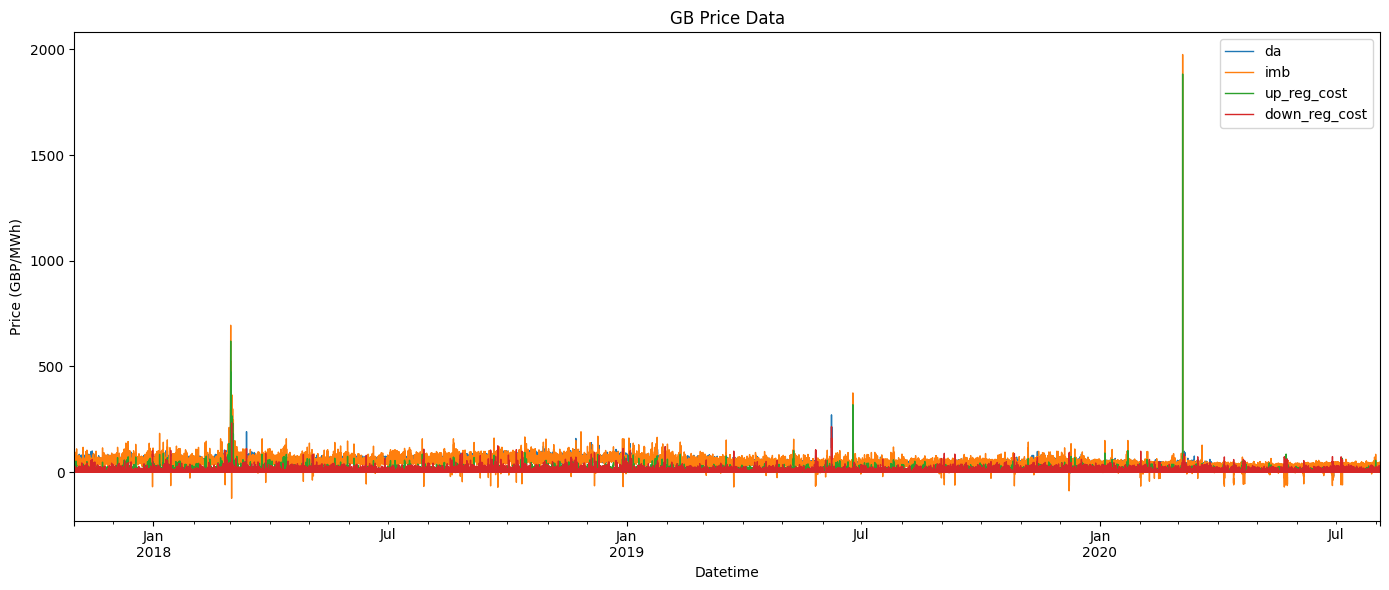

In [31]:
#time_start = '2017-11-01'
#time_end = '2017-12-31'
#.loc[time_start:time_end]

fig, ax = plt.subplots(figsize=(14, 6))
gb_price_final.plot(ax=ax, linewidth=1)
ax.set_xlabel('Datetime')
ax.set_ylabel('Price (GBP/MWh)')
ax.set_title(f'GB Price Data')
#ax.set_title(f'GB Price Data ({time_start} to {time_end})')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

In [16]:
gb_price_final

,da,imb,up_reg_cost,down_reg_cost
datetime,,,,
2017-11-01 00:00:00+00:00,43.590699,44.500,0.909301,0.000000
2017-11-01 01:00:00+00:00,40.188327,43.220,3.031673,0.000000
2017-11-01 02:00:00+00:00,32.936364,33.050,0.113636,0.000000
2017-11-01 03:00:00+00:00,30.419661,36.645,6.225339,0.000000
2017-11-01 04:00:00+00:00,29.937366,25.545,0.000000,4.392366
...,...,...,...,...
2020-08-03 19:00:00+00:00,38.494320,47.000,8.505680,0.000000
2020-08-03 20:00:00+00:00,37.738824,39.310,1.571176,0.000000
2020-08-03 21:00:00+00:00,32.261478,15.125,0.000000,17.136478
